## Group 4

### Problem Definition
#### Our goal of this project is to clean and prepare a laptop dataset for further analysis or machine learning to apply regression.
#### The dataset includes information about laptop specifications such as Brand, Model, RAM, Screen size, Storage type, GPU, and Final Price. 

#### The main objectives are:

- Clean the data by fixing missing values and errors.
- Understand how key features (like RAM, Screen size, and Price) are related to help choose important features.
- Prepare the data for further tasks, such as predicting laptop prices or grouping similar laptops together.
- Applying regression

In [1]:
# Read the data and display them
import pandas as pd
df = pd.read_csv('laptops.csv', delimiter=',')
display(df)
# dispaly the data information
df.info()

,Laptop,Status,Brand,Model,CPU,RAM,Storage,Storage type,GPU,Screen,Touch,Final Price
0,ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core...,New,Asus,ExpertBook,Intel Core i5,8.0,512,SSD,NaN,15.6,No,1009.00
1,Alurin Go Start Intel Celeron N4020/8GB/256GB ...,New,NaN,Go,Intel Celeron,8.0,256,SSD,NaN,15.6,No,299.00
2,ASUS ExpertBook B1 B1502CBA-EJ0424X Intel Core...,New,Asus,ExpertBook,Intel Core i3,8.0,256,SSD,NaN,15.6,No,789.00
3,MSI Katana GF66 12UC-082XES Intel Core i7-1270...,New,MSI,Katana,Intel Core i7,NaN,1000,SSD,RTX 3050,1000.0,No,1199.00
4,HP 15S-FQ5085NS Intel Core i5-1235U/16GB/512GB...,New,HP,15S,Intel Core i5,16.0,512,SSD,NaN,15.6,No,669.01
...,...,...,...,...,...,...,...,...,...,...,...,...
2155,Razer Blade 17 FHD 360Hz Intel Core i7-11800H/...,Refurbished,Razer,Blade,Intel Core i7,NaN,1000,SSD,RTX 3060,17.3,No,-2699.99
2156,Razer Blade 17 FHD 360Hz Intel Core i7-11800H/...,Refurbished,Razer,Blade,Intel Core i7,16.0,1000,SSD,RTX 3070,17.3,No,2899.99
2157,Razer Blade 17 FHD 360Hz Intel Core i7-11800H/...,Refurbished,NaN,Blade,Intel Core i7,32.0,1000,SSD,RTX 3080,17.3,No,3399.99
2158,Razer Book 13 Intel Evo Core i7-1165G7/16GB/1T...,Refurbished,Razer,Book,Intel Evo Core i7,16.0,1000,SSD,NaN,13.4,Yes,1899.99


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Laptop        2160 non-null   object 
 1   Status        2160 non-null   object 
 2   Brand         2153 non-null   object 
 3   Model         2160 non-null   object 
 4   CPU           2160 non-null   object 
 5   RAM           2137 non-null   float64
 6   Storage       2160 non-null   int64  
 7   Storage type  2118 non-null   object 
 8   GPU           789 non-null    object 
 9   Screen        2156 non-null   float64
 10  Touch         2160 non-null   object 
 11  Final Price   2160 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 202.6+ KB


In [2]:
# To show any missing value
print("\nMissing Data:")
print(df.isnull().sum())


Missing Data:
Laptop             0
Status             0
Brand              7
Model              0
CPU                0
RAM               23
Storage            0
Storage type      42
GPU             1371
Screen             4
Touch              0
Final Price        0
dtype: int64


### Data Collection
#### The dataset, laptops.csv, has 2160 rows and 12 columns. 
#### It contains both numerical and categorical data:

- Categorical Features: Brand, Model, CPU, GPU, Storage type, Touch, Status.
- Numerical Features: RAM, Screen size, Storage, Final Price.
- Target Variable: The target variable for this analysis is Final Price, which shows the price of the laptop.

#### Some columns had missing values:
- GPU had the most missing data (1371 missing entries).
- Brand, Storage type, and RAM had fewer missing values.
- The Final Price column contained negative values, which needed to be corrected.

### Feature Selection and Data Preprocessing

#### The following steps were used to clean and prepare the data:


In [3]:
# Fill missing values in 'RAM' with its median (due the outliers)
df['RAM'].fillna(df['RAM'].median(), inplace=True)

# Fill missing values in 'Screen' with its median (due the outliers)
df['Screen'].fillna(df['Screen'].median(), inplace=True)


In [4]:
# Fill missing values in 'Brand' with its mode
df['Brand'].fillna(df['Brand'].mode()[0], inplace=True)

# Fill missing values in 'Storage type' with its mode
df['Storage type'].fillna(df['Storage type'].mode()[0], inplace=True)

In [5]:
# Fill missing 'GPU' values with 'None' instead of dropping them, to avoid losing a huge number of data
df['GPU'] = df['GPU'].fillna('None')

#### Handling Missing Values:
- Numerical Features (RAM, Screen): Missing values were filled with the median to avoid the impact of outliers.
- Categorical Features (Brand, Storage type): Missing values were filled with the mode, which is the most common category.
- GPU: Missing GPU entries were replaced with "None" to prevent losing too much data.

In [6]:
#Listing the negative values in price
print("\nNegative values in 'Price' column:")
negative_values = df['Final Price'][df['Final Price'] < 0]
print(negative_values)

#Applying absolte value on negative prices
df["Final Price"]=df["Final Price"].apply(lambda x: abs(x) if x<0 else x)

      
#Listing outliers in Screen 
Q1 = df['Screen'].quantile(0.25)
Q3 = df['Screen'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
#outliers = df[(df['Screen'] < lower_bound) | (df['Screen'] > upper_bound)]
outliers = df['Screen'][(df['Screen'] < lower_bound) | (df['Screen'] > upper_bound)]
print("\nOutliers in 'Screen' column:")
print(outliers)

      
#  selecting rows excluding outliers in Screen
df = df[(df['Screen'] >= lower_bound) & (df['Screen'] <= upper_bound)]


Negative values in 'Price' column:
5      -1699.00
10      -349.00
21      -789.00
37      -399.00
66     -2499.00
208    -1799.00
335     -809.45
487    -2899.00
574    -1599.00
911    -1899.00
1458   -1192.98
1494    -531.34
1544   -1354.18
1610    -663.90
1656   -1029.99
1719    -477.59
1815    -794.74
1907    -912.44
1987   -1779.00
2034    -861.99
2102   -1899.00
2140   -1949.90
2155   -2699.99
Name: Final Price, dtype: float64

Outliers in 'Screen' column:
3       1000.00
58       200.00
477       11.60
497       10.50
654       11.60
708       11.60
728       11.60
817       11.60
869       11.60
961       11.60
964       11.60
968       10.50
984       10.10
1034      11.60
1040      10.95
1055      11.60
1209      11.60
1210      11.60
1427      11.60
1428      11.60
1487      11.60
1488      11.60
1616      10.50
1617      10.50
1618      10.50
1619      10.50
1620      10.50
Name: Screen, dtype: float64


#### Handling Negative Prices:
- Final Price: Negative values were found and converted to positive values to fix any data errors.


#### Outlier Detection and Treatment:
- Screen size: Outliers (values far from the norm) were identified using the Interquartile Range (IQR) method and removed to improve the data's reliability.

In [7]:
display(df)
print(df.isnull().sum())

,Laptop,Status,Brand,Model,CPU,RAM,Storage,Storage type,GPU,Screen,Touch,Final Price
0,ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core...,New,Asus,ExpertBook,Intel Core i5,8.0,512,SSD,None,15.6,No,1009.00
1,Alurin Go Start Intel Celeron N4020/8GB/256GB ...,New,Asus,Go,Intel Celeron,8.0,256,SSD,None,15.6,No,299.00
2,ASUS ExpertBook B1 B1502CBA-EJ0424X Intel Core...,New,Asus,ExpertBook,Intel Core i3,8.0,256,SSD,None,15.6,No,789.00
4,HP 15S-FQ5085NS Intel Core i5-1235U/16GB/512GB...,New,HP,15S,Intel Core i5,16.0,512,SSD,None,15.6,No,669.01
5,MSI Crosshair 17 C12VF-264XES Intel Core i7-12...,New,MSI,Crosshair,Intel Core i7,32.0,1000,SSD,RTX 4060,17.3,No,1699.00
...,...,...,...,...,...,...,...,...,...,...,...,...
2155,Razer Blade 17 FHD 360Hz Intel Core i7-11800H/...,Refurbished,Razer,Blade,Intel Core i7,16.0,1000,SSD,RTX 3060,17.3,No,2699.99
2156,Razer Blade 17 FHD 360Hz Intel Core i7-11800H/...,Refurbished,Razer,Blade,Intel Core i7,16.0,1000,SSD,RTX 3070,17.3,No,2899.99
2157,Razer Blade 17 FHD 360Hz Intel Core i7-11800H/...,Refurbished,Asus,Blade,Intel Core i7,32.0,1000,SSD,RTX 3080,17.3,No,3399.99
2158,Razer Book 13 Intel Evo Core i7-1165G7/16GB/1T...,Refurbished,Razer,Book,Intel Evo Core i7,16.0,1000,SSD,None,13.4,Yes,1899.99


Laptop          0
Status          0
Brand           0
Model           0
CPU             0
RAM             0
Storage         0
Storage type    0
GPU             0
Screen          0
Touch           0
Final Price     0
dtype: int64


### Exploratory Data Analysis (EDA):

In [9]:
# Statistical summary for numerical data
print('Statistical summary for numerical:')
numericdata = df.select_dtypes(include="number")
nsummary = numericdata.describe()  # summary for numeric data
nsummary.loc['median'] = numericdata.median()  # add median
nsummary.loc['mode'] = numericdata.mode().iloc[0]  # add mode
nsummary.loc['range'] = numericdata.max() - numericdata.min()  # add range
print(nsummary)

# Statistical summary for categorical data
print('\nStatistical summary for categorical:')
categoricalcolumns = df.select_dtypes(include=['object'])
#using loop to get each colum summry
for column in categoricalcolumns.columns:
    freq = categoricalcolumns[column].value_counts() #get frequncy
    percent = categoricalcolumns[column].value_counts(normalize=True) * 100 #the percentege
    mode = categoricalcolumns[column].mode()[0] #if not categoricalcolumns[column].mode().empty else None #the mode
    #add them in summary:
    summary = pd.DataFrame({
        'Frequency': freq,
        'Percentage': percent
    })
    print(f"\nSummary for column: {column}")
    print(summary)
    #tell the mode of each colume
    print(f"Mode: {mode}")

Statistical summary for numerical:
                RAM      Storage       Screen  Final Price
count   2133.000000  2133.000000  2133.000000  2133.000000
mean      15.522738   601.978434    15.214955  1322.273797
std        9.730856   359.259810     1.128767   912.590126
min        4.000000     0.000000    12.000000   201.050000
25%        8.000000   256.000000    14.000000   669.010000
50%       16.000000   512.000000    15.600000  1043.940000
75%       16.000000  1000.000000    15.600000  1724.990000
max      128.000000  4000.000000    18.000000  7150.470000
median    16.000000   512.000000    15.600000  1043.940000
mode      16.000000   512.000000    15.600000   999.000000
range    124.000000  4000.000000     6.000000  6949.420000

Statistical summary for categorical:

Summary for column: Laptop
                                                    Frequency  Percentage
ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core ...          1    0.046882
HP EliteBook 840 G9 Intel Core i5-1235U/16G

##### Statistical Summary for Numerical Data:
- A statistical summary was generated for the numerical columns, including measures of central tendency (mean, median, mode) and dispersion (standard deviation, range). 
- This provided insights into the distribution and variability of the numerical features.

##### Statistical Summary for Categorical Data:
- The categorical columns were analyzed to identify the frequency and percentage of each category. 
- The mode for each column was also determined to highlight the most common category.

#### Distribution of Features:

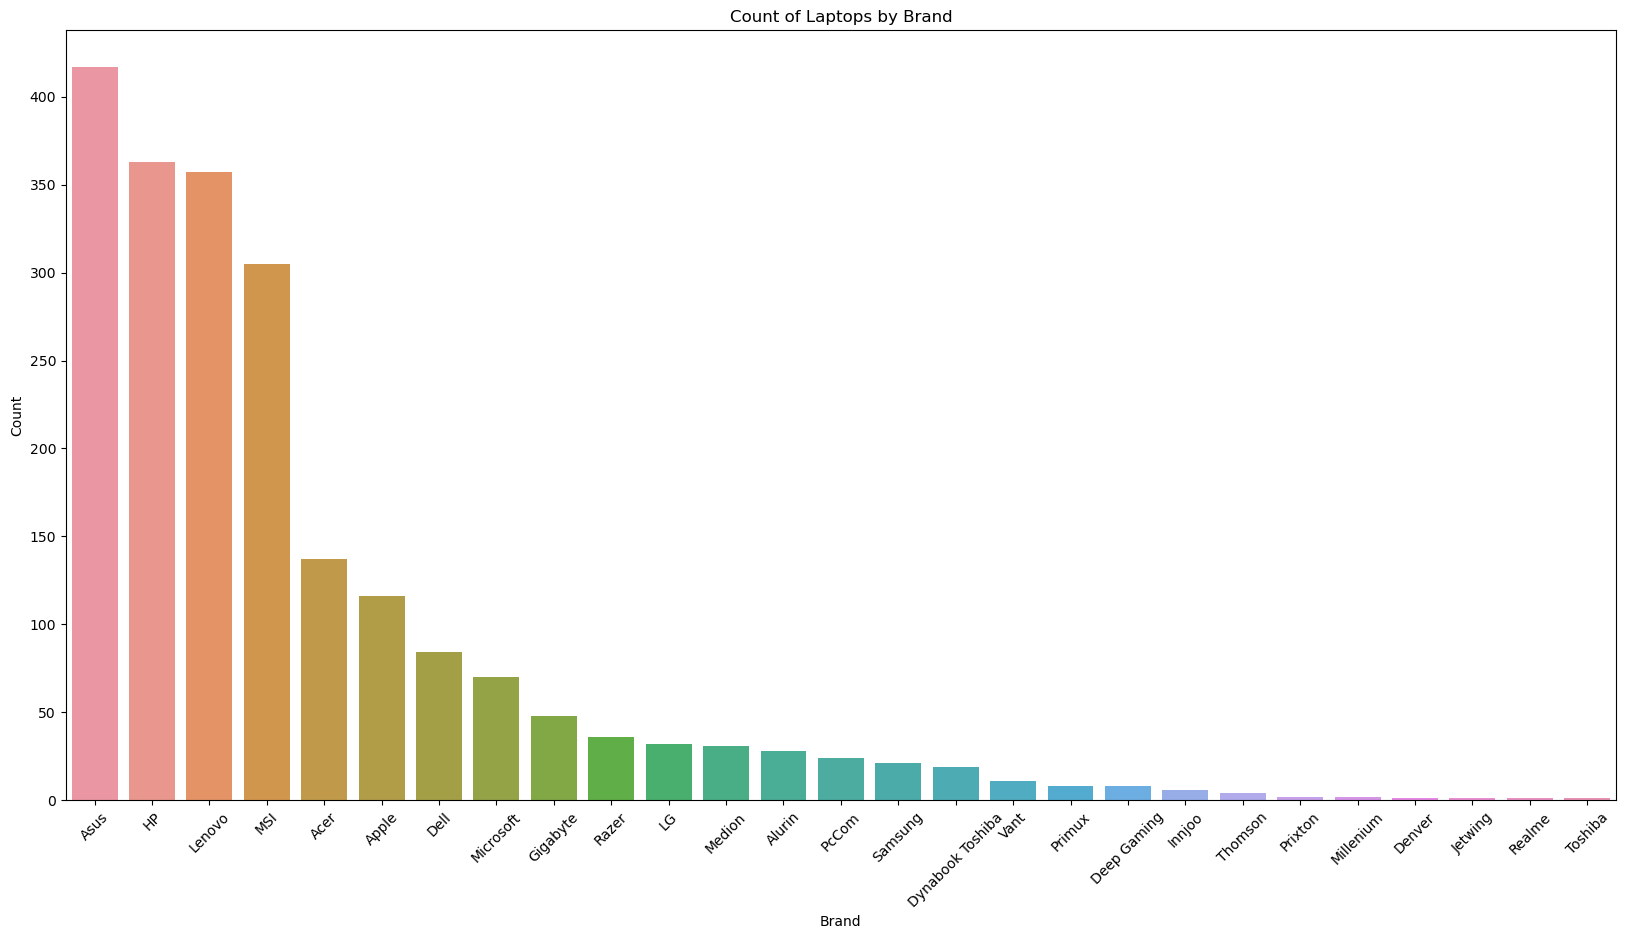

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Histogram for counts of laptops by brand (Categorical)
plt.figure(figsize=(20, 10))
sns.countplot(x='Brand', data=df, order=df['Brand'].value_counts().index)
plt.title('Count of Laptops by Brand')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()
########################### WE CAN IGNORE IT SINCE IT DOES NOT GIVE VALUABLE INFORMATION 
########################### ALSO, THE BRANDS ARE A LOT AND IT IS HARD TO CONVERT INTO NUMERICAL

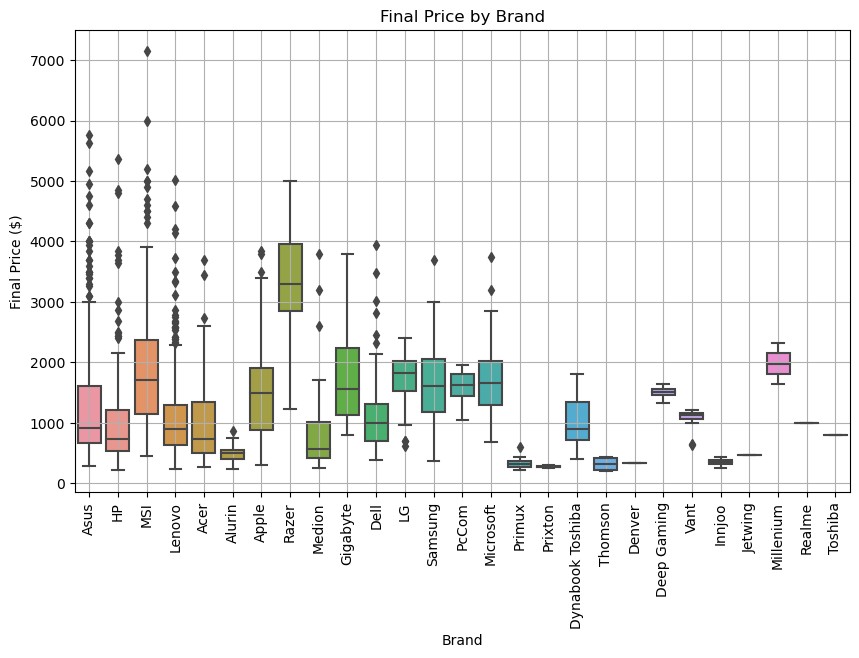

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Brand', y='Final Price', data=df) # to show the median and the outliers
plt.title('Final Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Final Price ($)')
plt.xticks(rotation=90)
plt.grid()
plt.show()

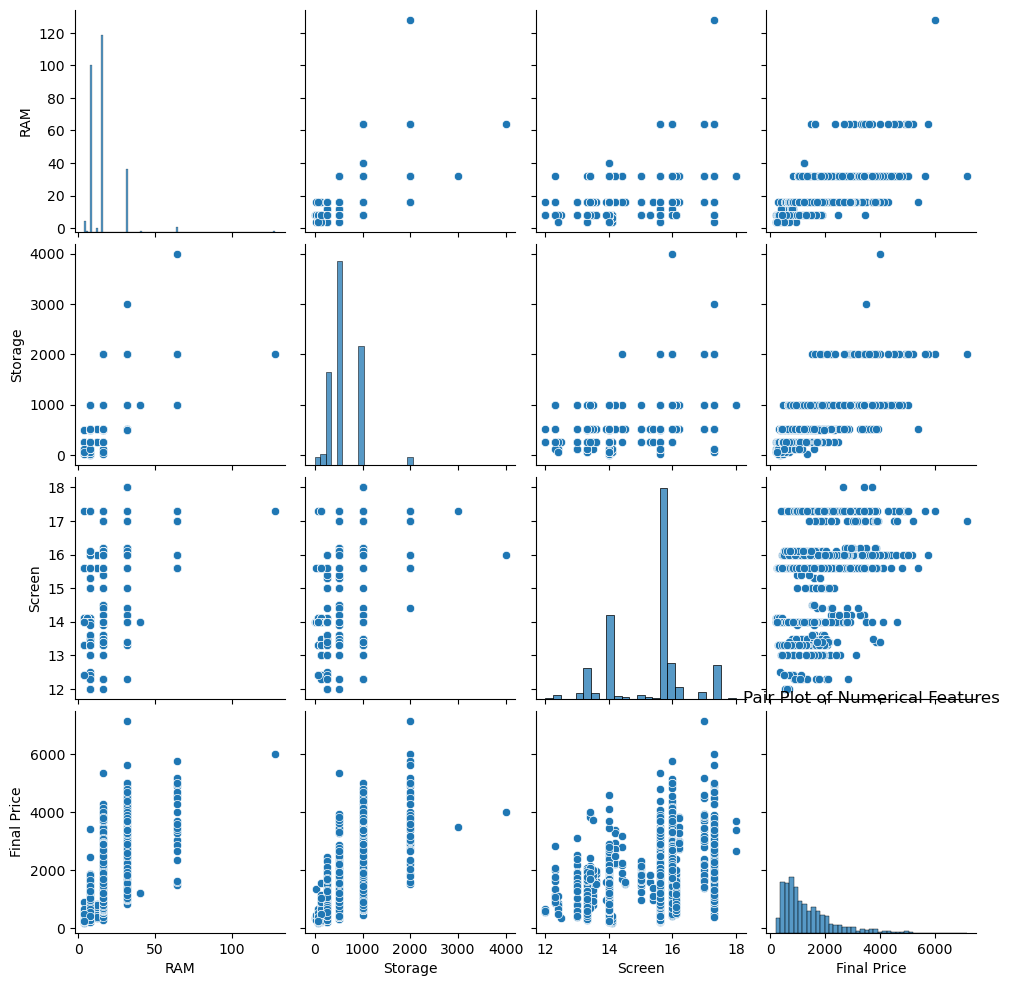

In [177]:
numerical_columns = ['RAM', 'Storage', 'Screen', 'Final Price']  # Add other numerical columns if necessary
categorical_columns = ['Brand', 'CPU', 'Storage type', 'Touch']  # Include relevant categorical columns
# exploring the correlation between numerical values
sns.pairplot(df[numerical_columns])
plt.title('Pair Plot of Numerical Features')
plt.show()

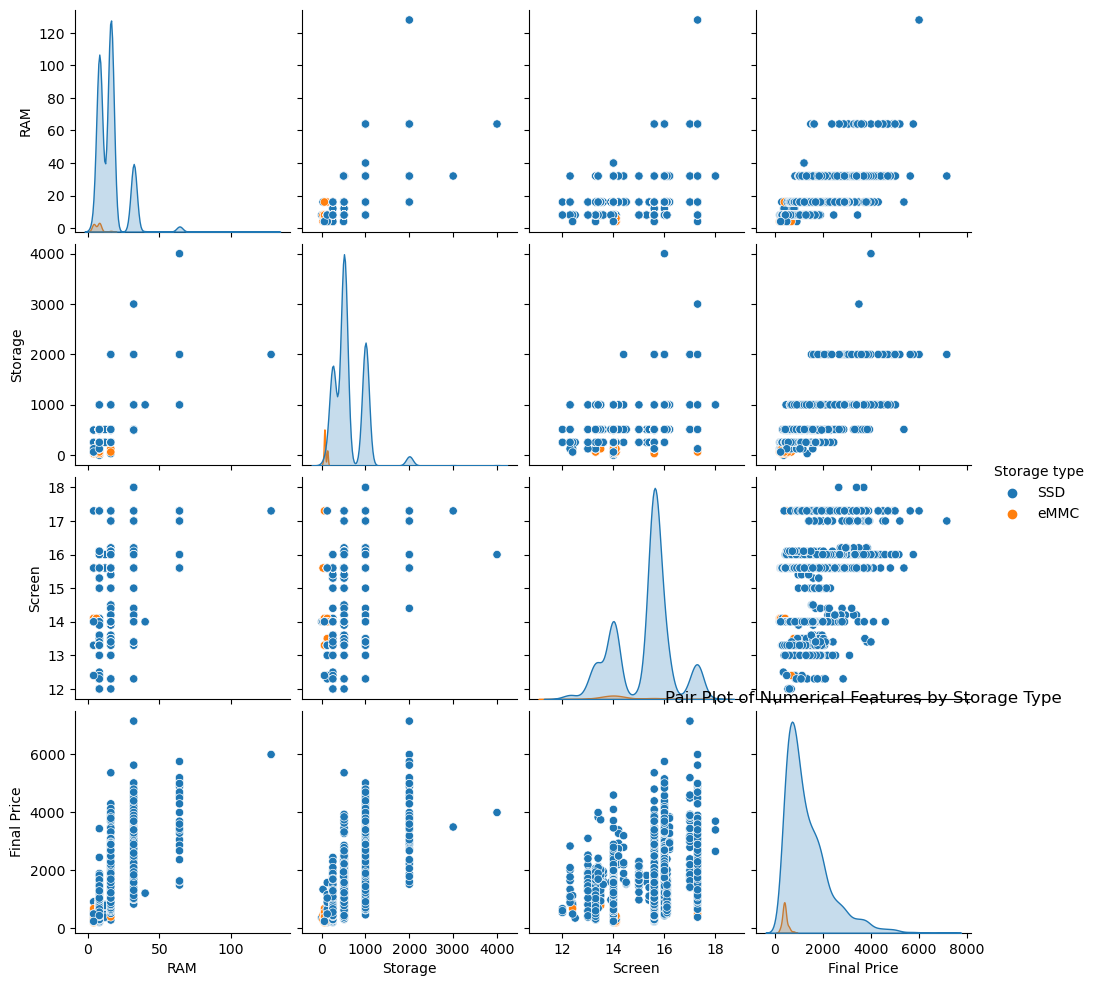

In [179]:
# To differentiate by Storage type 
sns.pairplot(df[numerical_columns + ['Storage type']], hue='Storage type')
plt.title('Pair Plot of Numerical Features by Storage Type')
plt.show()


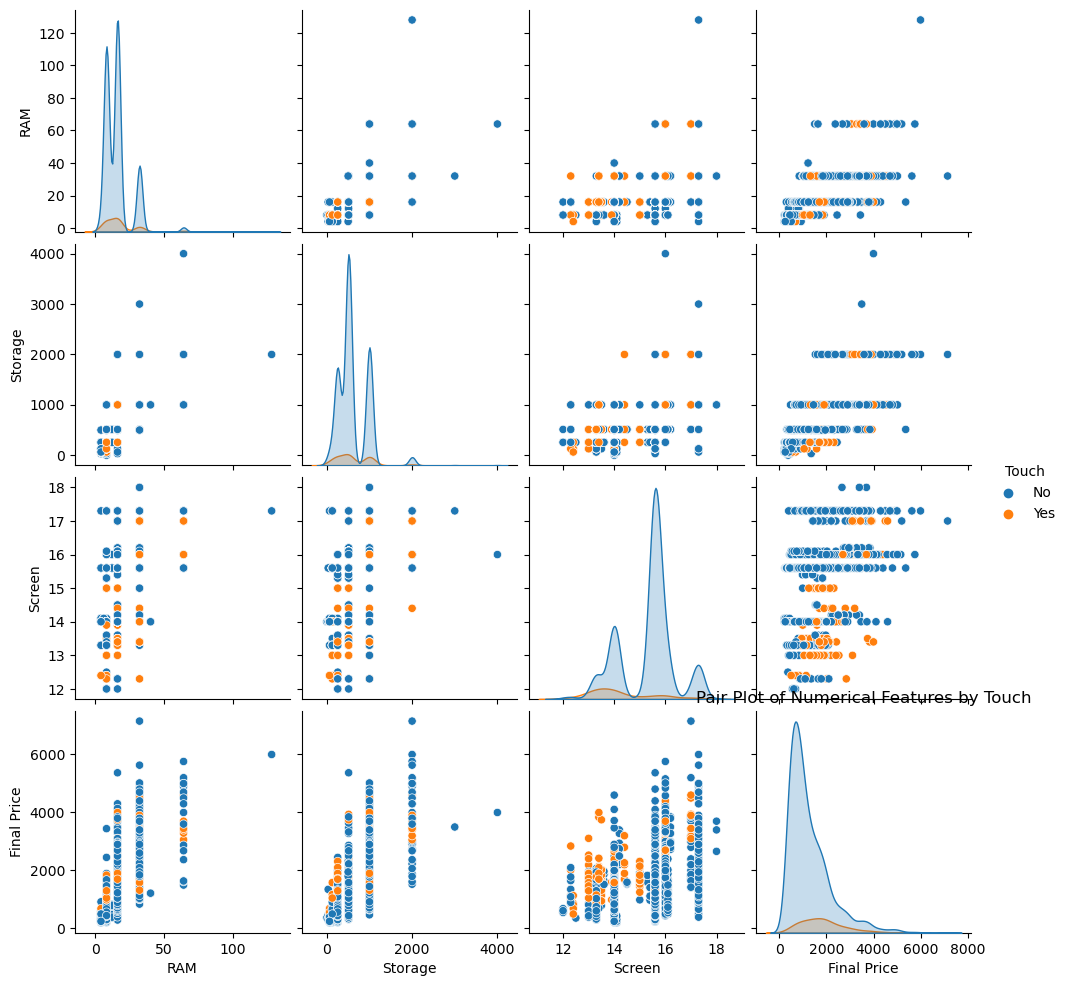

In [180]:
# To differentiate by Touch
sns.pairplot(df[numerical_columns + ['Touch']], hue='Touch')
plt.title('Pair Plot of Numerical Features by Touch')
plt.show()

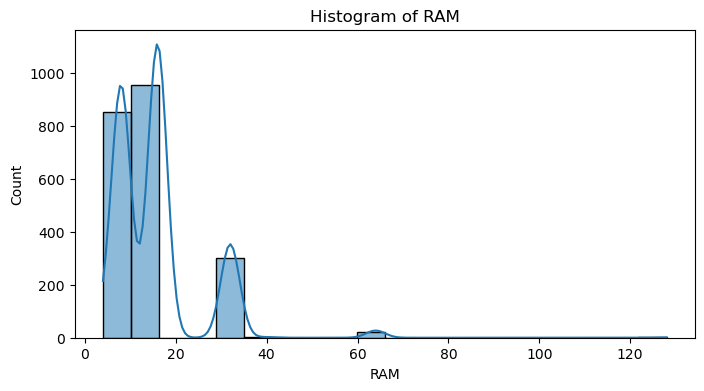

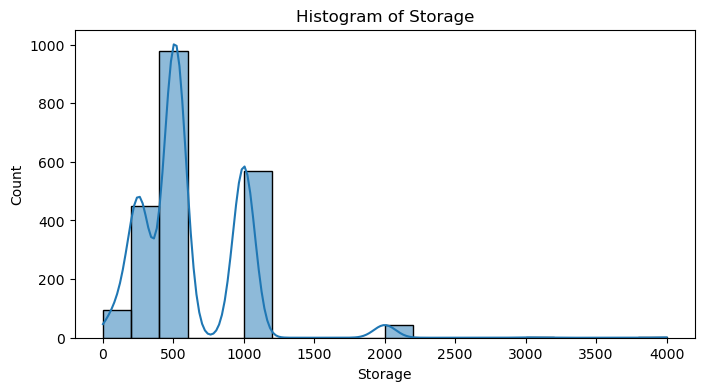

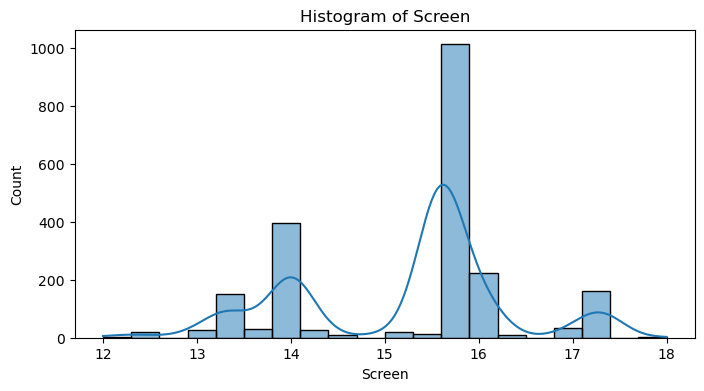

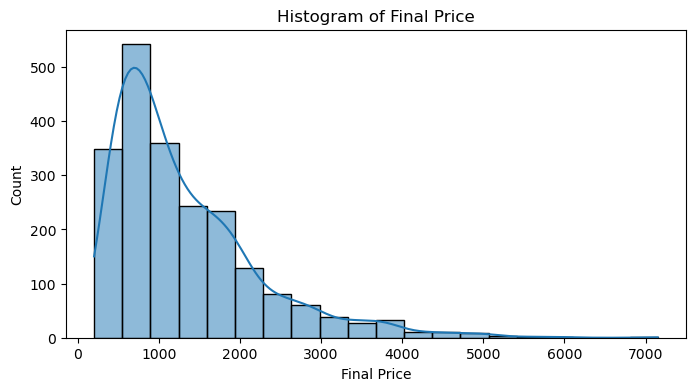

In [14]:
# Histograms for numerical features ( COUNT OF RAM AND FINAL PRICE )
num_columns = ['RAM', 'Storage', 'Screen', 'Final Price']
for col in num_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Histogram of {col}')
    plt.show()

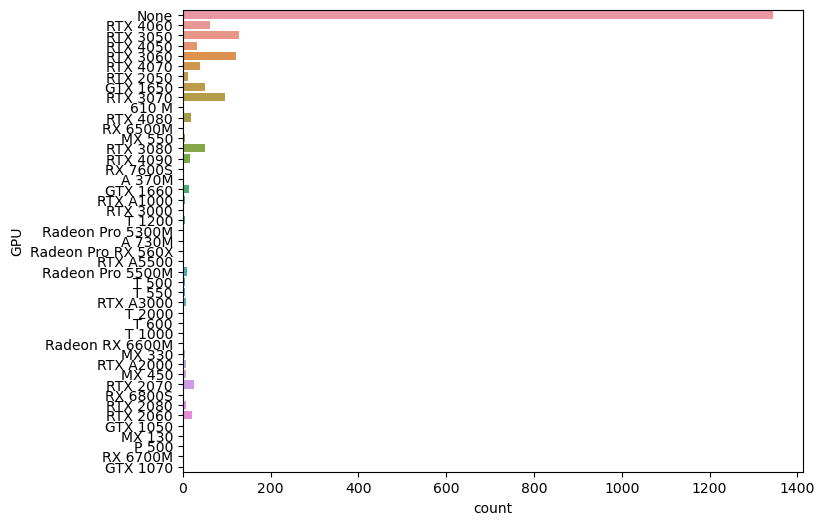

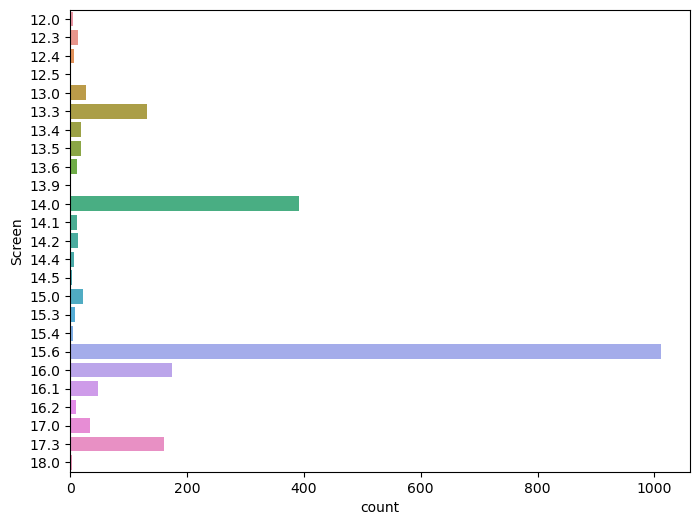

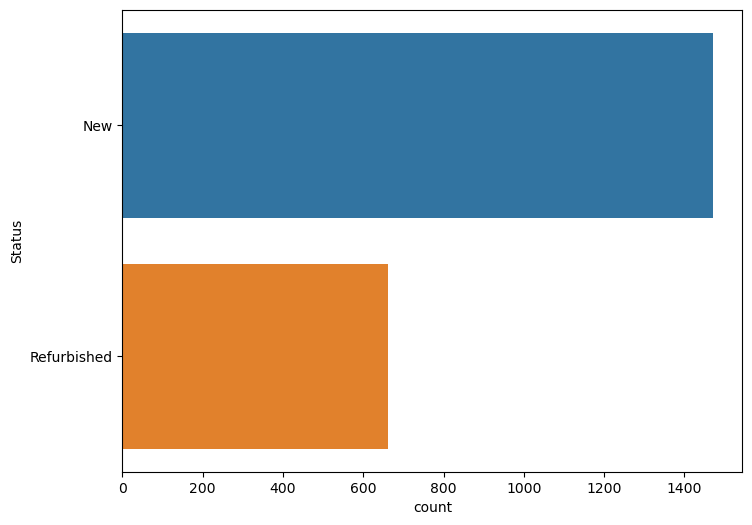

In [19]:
categorical_columns = ['GPU', 'Screen','Status'] 
for col in categorical_columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(y=col, data=df)
    plt.show()


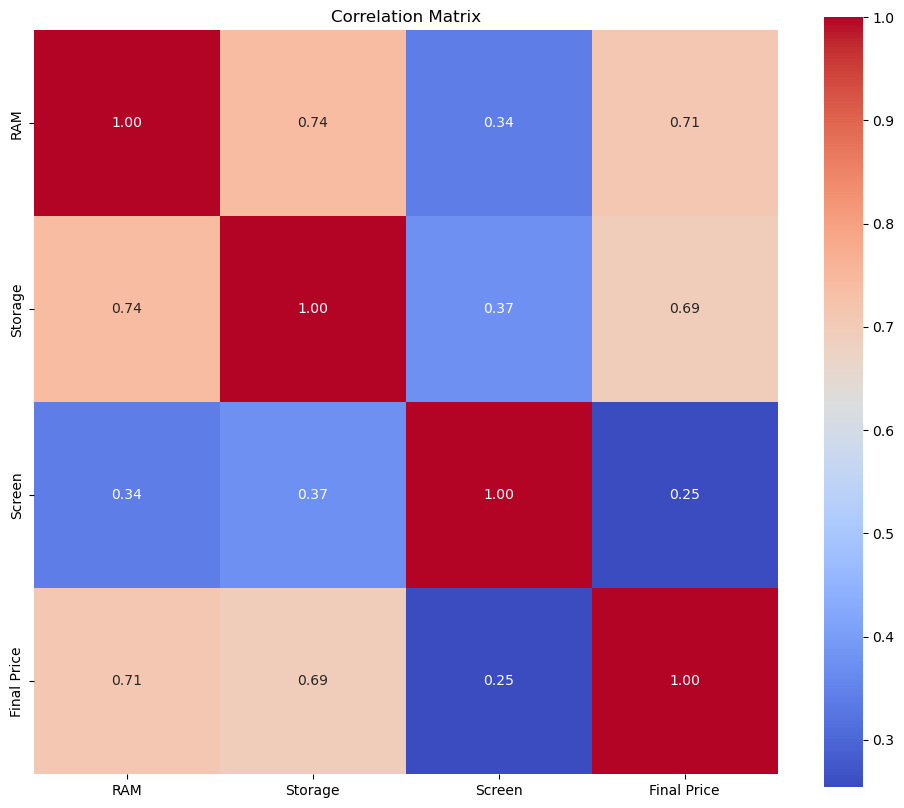

In [183]:
########################################################################################
# Calculate the correlation matrix
correlation = df.corr(numeric_only=True)

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Create a heatmap for the correlation matrix
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm', square=True)
#annot=True # Adds annotations (numerical values) on each cell of the heatmap.
plt.title('Correlation Matrix')
plt.show()

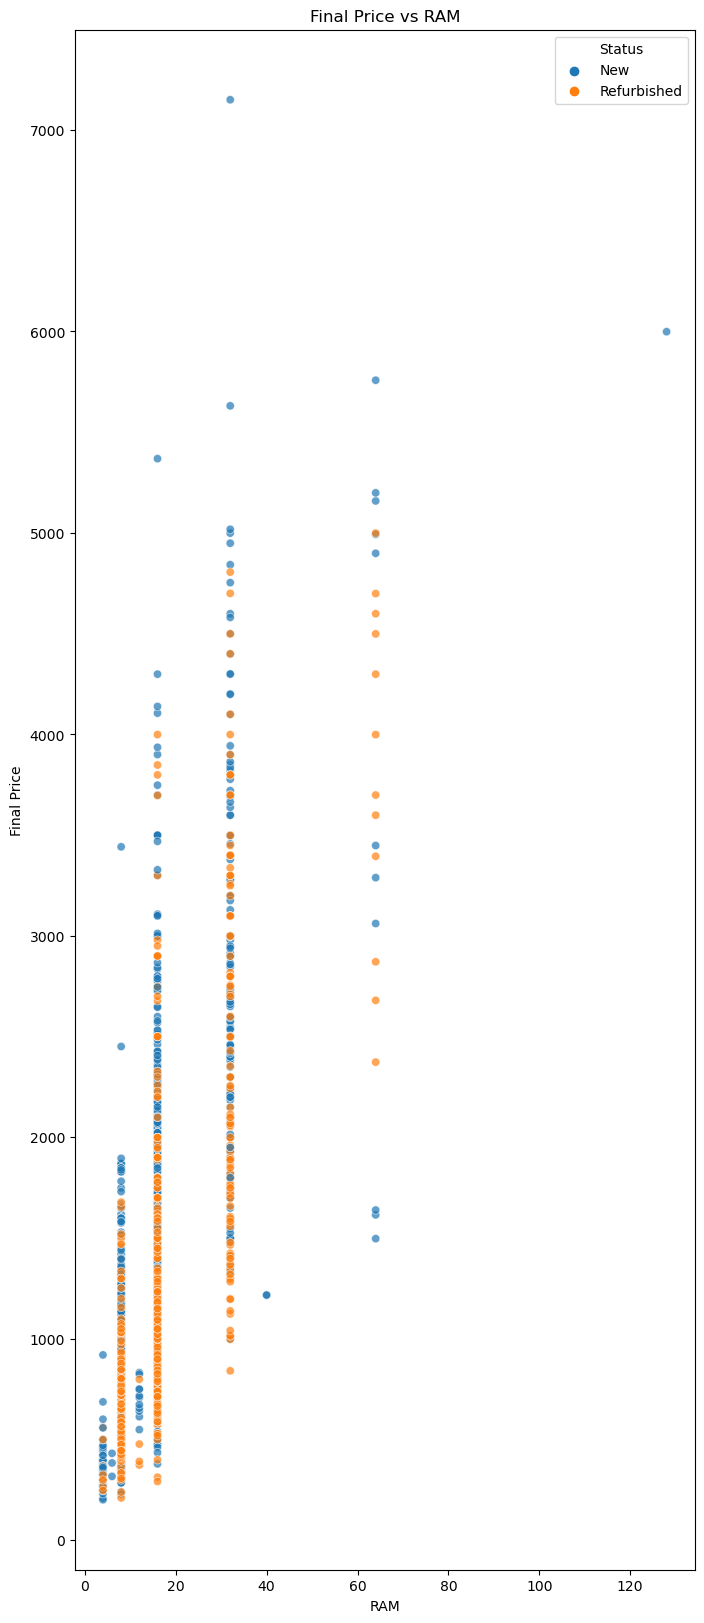

In [184]:
# Scatter plot of Final Price vs RAM (numerical)
plt.figure(figsize=(8, 20))
sns.scatterplot(x='RAM', y='Final Price', data=df, hue='Status', alpha=0.7)
plt.title('Final Price vs RAM')
plt.show()

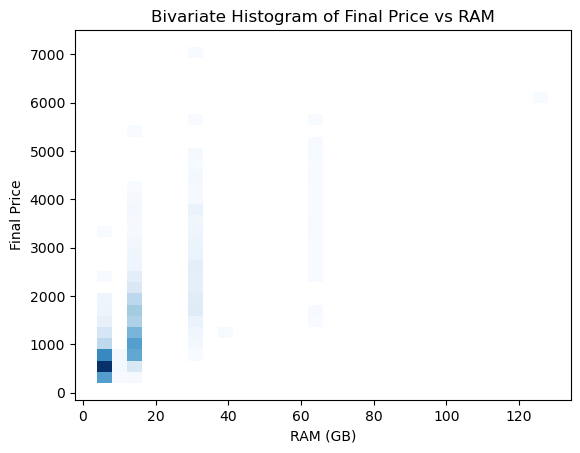

In [22]:
sns.histplot(data=df, x='RAM', y='Final Price', bins=30, cmap='Blues')
plt.title('Bivariate Histogram of Final Price vs RAM')
plt.xlabel('RAM (GB)')
plt.ylabel('Final Price')
plt.show()

##### Histograms and count plots were used to visualize the distribution of numerical and categorical variables: 
- RAM and Final Price had skewed distributions, meaning most laptops had lower prices and less RAM.
- Examining Brands and Status helped identify trends in the most common laptop types.

#### Outliers:
- Boxplots showed potential outliers for final price by Brand.

#### Correlation Heatmaps identified key relationships:
- RAM and Final Price showed a positive correlation, meaning laptops with more RAM tend to have a higher price.
- Storage also had a relationship with Final Price, suggesting this feature could help predict laptop prices.
- Screen size had less relationship with Final Price

#### Relationships Between Features:
- Scatter Plots and Pair Plots showed how features like RAM were related to Final Price.


In [24]:
# get the unique value in each column
unique_counts = df.nunique()
print(unique_counts)

Laptop          2133
Status             2
Brand             27
Model            117
CPU               26
RAM                9
Storage           12
Storage type       2
GPU               45
Screen            25
Touch              2
Final Price     1419
dtype: int64


#### Encoding Categorical Variables:
- One-Hot Encoding: Applied to features like Brand, Model, CPU, and GPU to turn them into numbers that can be used by machine learning algorithms.
- Label Encoding: Applied to binary features (e.g., Touch, Storage type, Status) to convert them into 0 or 1.


In [25]:
from sklearn.preprocessing import LabelEncoder
# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=['Brand', 'Model', 'CPU', 'GPU'], drop_first=True)

# Initialize LabelEncoder for 'Touch','Storage type', and 'Status'
label_encoder = LabelEncoder()

# Apply LabelEncoder to 'Touch'
df_encoded['Touch'] = label_encoder.fit_transform(df['Touch'])

# Apply LabelEncoder to 'Status'
df_encoded['Status'] = label_encoder.fit_transform(df['Status'])

# Apply LabelEncoder to 'Storage type'
df_encoded['Storage type'] = label_encoder.fit_transform(df['Storage type'])

# Display the transformed DataFrame
display(df_encoded.head())

,Laptop,Status,RAM,Storage,Storage type,Screen,Touch,Final Price,Brand_Alurin,Brand_Apple,...,GPU_Radeon Pro 5300M,GPU_Radeon Pro 5500M,GPU_Radeon Pro RX 560X,GPU_Radeon RX 6600M,GPU_T 1000,GPU_T 1200,GPU_T 2000,GPU_T 500,GPU_T 550,GPU_T 600
0,ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core...,0,8.0,512,0,15.6,0,1009.00,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Alurin Go Start Intel Celeron N4020/8GB/256GB ...,0,8.0,256,0,15.6,0,299.00,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ASUS ExpertBook B1 B1502CBA-EJ0424X Intel Core...,0,8.0,256,0,15.6,0,789.00,0,0,...,0,0,0,0,0,0,0,0,0,0
4,HP 15S-FQ5085NS Intel Core i5-1235U/16GB/512GB...,0,16.0,512,0,15.6,0,669.01,0,0,...,0,0,0,0,0,0,0,0,0,0
5,MSI Crosshair 17 C12VF-264XES Intel Core i7-12...,0,32.0,1000,0,17.3,0,1699.00,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
# Drop the 'Laptop' column as it is not useful for regression
df_encoded = df_encoded.drop('Laptop', axis=1)

# Display the updated DataFrame
display(df_encoded)

,Status,RAM,Storage,Storage type,Screen,Touch,Final Price,Brand_Alurin,Brand_Apple,Brand_Asus,...,GPU_Radeon Pro 5300M,GPU_Radeon Pro 5500M,GPU_Radeon Pro RX 560X,GPU_Radeon RX 6600M,GPU_T 1000,GPU_T 1200,GPU_T 2000,GPU_T 500,GPU_T 550,GPU_T 600
0,0,8.0,512,0,15.6,0,1009.00,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,8.0,256,0,15.6,0,299.00,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,8.0,256,0,15.6,0,789.00,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,16.0,512,0,15.6,0,669.01,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,32.0,1000,0,17.3,0,1699.00,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2155,1,16.0,1000,0,17.3,0,2699.99,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2156,1,16.0,1000,0,17.3,0,2899.99,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2157,1,32.0,1000,0,17.3,0,3399.99,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2158,1,16.0,1000,0,13.4,1,1899.99,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Feature Removal:
- The Laptop column was removed because it wasn’t useful for predicting laptop prices.

#### Up to this phase we successfully cleaned, processed, and analyzed the laptop dataset, preparing it for future machine learning tasks. 
#### Our main steps included filling missing values, fixing negative prices, removing outliers, visualizing the data, and encoding categorical features into numerical ones.

### Data Preprocessing and Splitting:

In [27]:
# Get a statistical summary of the dataframe after encoding the data (transpose it for easier reading)
df_encoded.describe().T

,count,mean,std,min,25%,50%,75%,max
Status,2133.0,0.310361,0.462750,0.0,0.0,0.0,1.0,1.0
RAM,2133.0,15.522738,9.730856,4.0,8.0,16.0,16.0,128.0
Storage,2133.0,601.978434,359.259810,0.0,256.0,512.0,1000.0,4000.0
Storage type,2133.0,0.022035,0.146831,0.0,0.0,0.0,0.0,1.0
Screen,2133.0,15.214955,1.128767,12.0,14.0,15.6,15.6,18.0
...,...,...,...,...,...,...,...,...
GPU_T 1200,2133.0,0.002813,0.052975,0.0,0.0,0.0,0.0,1.0
GPU_T 2000,2133.0,0.000469,0.021652,0.0,0.0,0.0,0.0,1.0
GPU_T 500,2133.0,0.002344,0.048371,0.0,0.0,0.0,0.0,1.0
GPU_T 550,2133.0,0.001875,0.043274,0.0,0.0,0.0,0.0,1.0


In [28]:
# Generate Train - Test splits
from sklearn.model_selection import train_test_split

# Selecting all columns except the 6th column as features (X)
X = df_encoded.iloc[:, df_encoded.columns != df_encoded.columns[6]]  # Exclude the column at index 6 as target

# Set 'Final Price' as the target variable (y)
y = df_encoded['Final Price'].values  # Final price column as target variable

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [29]:
# Scaling the Train - Test splits to normalize the data
import numpy as np
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler for data normalization
scaler = StandardScaler()

# Fit the scaler on the training data (X_train + y_train combined)
scaler.fit(np.c_[X_train, y_train])  # Scaling the combined data (features + target)

# Apply the scaling transformation to the training data
A_train = scaler.transform(np.c_[X_train, y_train])  # Apply scaling transformation
X_train = A_train[:, :-1]  # Select all columns except the last one as features (X_train)
y_train = A_train[:, -1]  # Select the last column as target (y_train)

# Apply the scaling transformation to the test data
A_test = scaler.transform(np.c_[X_test, y_test])  # Apply scaling transformation
X_test = A_test[:, :-1]  # Select all columns except the last one as features (X_test)
y_test = A_test[:, -1]  # Select the last column as target (y_test)

# Print the scaled training data for review
print(A_train)

[[-0.66215449  0.05275332 -0.27036675 ... -0.04847862 -0.03425944
  -0.62675712]
 [ 1.51022158  1.66344087  1.10513925 ... -0.04847862 -0.03425944
   0.84091672]
 [-0.66215449  1.66344087  1.10513925 ... -0.04847862 -0.03425944
   2.11433961]
 ...
 [ 1.51022158 -0.75259045 -0.23735461 ... -0.04847862 -0.03425944
  -0.5294266 ]
 [-0.66215449  1.66344087  1.10513925 ... -0.04847862 -0.03425944
   0.16751343]
 [-0.66215449  0.05275332 -0.23735461 ... -0.04847862 -0.03425944
  -0.27063038]]


#### Dataset Splitting:
- The dataset was divided into 80% training data and 20% testing data using train_test_split from scikit-learn.

#### Target Variable:
- The target variable, "Final Price", was separated from the feature columns.

#### Data Scaling:
- The feature data was standardized using StandardScaler to ensure all features have the same scale and contribute equally to the model.
- Both the training and testing datasets were scaled before model training.

#### Model Readiness:
- After scaling, the data was prepared for model training and evaluation, with the target variable separated out for future predictions.

### Regression Analysis

In [30]:
# Regression Analysis: Mean Squared Error Metric
from sklearn.metrics import mean_squared_error

## OLS
from sklearn.linear_model import LinearRegression
reg1=LinearRegression(fit_intercept= False).fit(X_train, y_train)
Y_pred1 = reg1.predict(X_test)
print("The MSE using OLS is:", mean_squared_error(y_test, Y_pred1))


## Ridge
from sklearn.linear_model import RidgeCV
reg2=RidgeCV(alphas=[1e-3, 1e-2 , 1e-1 , 1e0 , 1e1 , 1e2 , 1e3], fit_intercept= False,cv=10).fit(X_train, y_train)
Y_pred2 = reg2.predict(X_test)
print("The MSE using RIDGE is:", mean_squared_error(y_test, Y_pred2))


## Lasso
from sklearn.linear_model import LassoCV
reg3 = LassoCV(alphas=[1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3], 
               fit_intercept=False, cv=10, random_state=0).fit(X_train, y_train)
## fit_intercept=False because we standardized the data
Y_pred3 = reg3.predict(X_test)
print("The MSE using Lasso is:", mean_squared_error(y_test, Y_pred3))

The MSE using OLS is: 1.8515972147296377e+25
The MSE using RIDGE is: 0.11701997843693406
The MSE using Lasso is: 0.11564902313866812


#### based on the best values for the estimates are the values optained by Lasso since it performs better than Ridge and OLS.


In [33]:
print(" The best penalty coefficient:", reg3.alpha_)
print('\n')
reg3_coef = np.round(reg3.coef_,2)
print(" The best coefficient estimates are:", reg3_coef.tolist())


 The best penalty coefficient: 0.001


 The best coefficient estimates are: [-0.12, 0.14, 0.19, 0.01, 0.03, 0.11, -0.02, 0.06, -0.0, -0.05, 0.02, -0.0, 0.0, 0.0, -0.02, -0.01, -0.0, 0.0, 0.0, 0.0, -0.0, 0.08, 0.02, 0.0, -0.02, -0.0, 0.0, 0.0, 0.0, -0.01, -0.0, -0.0, 0.01, -0.04, -0.0, -0.0, -0.0, -0.02, -0.0, 0.0, 0.0, 0.01, 0.01, -0.01, -0.0, -0.0, -0.01, -0.02, 0.0, -0.01, 0.14, 0.02, 0.0, 0.0, -0.0, -0.0, 0.01, 0.01, -0.0, -0.01, 0.0, 0.01, 0.0, -0.01, -0.0, -0.0, 0.08, 0.07, 0.0, -0.02, 0.01, -0.02, 0.0, -0.0, -0.01, -0.0, -0.01, -0.01, 0.0, 0.0, 0.0, 0.04, -0.01, 0.04, -0.02, -0.0, -0.0, 0.0, 0.03, 0.02, -0.01, -0.0, -0.01, 0.0, 0.05, -0.0, -0.01, -0.0, -0.0, -0.0, -0.0, -0.01, -0.0, -0.0, -0.02, 0.0, -0.0, 0.0, 0.03, 0.04, -0.01, 0.01, -0.01, 0.03, -0.01, 0.02, 0.06, 0.0, -0.01, 0.0, 0.03, 0.0, 0.0, 0.0, 0.0, -0.03, 0.02, -0.02, 0.04, 0.09, 0.03, -0.01, 0.01, 0.01, 0.01, -0.03, 0.0, 0.0, 0.01, -0.01, -0.04, -0.0, -0.0, 0.06, 0.04, 0.04, 0.14, 0.01, -0.01, -0.01, -0.0, 0.06, -0.02

### Summary 
Our team developed a regression model to predict laptop prices based on various features extracted from a dataset. We performed data preprocessing, including cleaning missing values, encoding categorical variables, and removing outliers. Afterward, we explored the dataset using visual and statistical analysis to gain insights into feature distributions and relationships. This included generating count plots, histograms, pair plots, box plots, and a heatmap showing feature correlations.
We then split the dataset into training and testing sets and we scaled features for consistency, applied multiple regression models (OLS, Ridge, and Lasso), and evaluated their performance using Mean Squared Error (MSE). Among the models, Lasso Regression provided the best results due to its feature selection capability and lower MSE, making it the most suitable model for our task.

### Communicate results
- OLS Regression: The MSE was extremely high (1.85 × 10²⁵), indicating significant prediction errors. This result suggests that the OLS model was highly sensitive and lacked regularization, making it unsuitable.

- Ridge Regression: The MSE was 0.1170, showing a notable improvement. Ridge reduced overfitting, controlling large feature coefficients without eliminating them entirely.

- Lasso Regression: The best-performing model was Lasso Regression, with an MSE of 0.1156. Lasso not only reduced overfitting but also performed automatic feature selection by shrinking less important coefficients to zero.
- The results indicate that Lasso Regression is the most suitable model for predicting laptop prices. 

### Operationalize 
##### To adopt our methodology, follow these steps:
   - Set up the development environment
   - Load and preprocess data
   - Train the model
   - Evaluate the model
   - Make predictions for new laptops: Input New Laptop Features, preprocess the new input by encoding and scaling, then predict price
   - Future improvements could involve adding more relevant features to improve the model's performance. 
##### Problems during building the model:
   - The data contained lots of missing values 
   - The data contained lots of outliers
   - The brand column has a lot of data, making it hard to be visualized
   